In [1]:
import pandas as pd
df = pd.read_excel('../data/DGA_train.xlsx')
df.shape


(584, 6)

In [2]:
df.columns.tolist()

['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2', 'Fault class']

In [3]:
df.head(10)

,H2,CH4,C2H6,C2H4,C2H2,Fault class
0,1076.00,95.000,4.000,71.000,231.0000,1
1,407.00,28.000,15.000,21.000,0.0001,1
2,2240.00,560.000,380.000,450.000,940.0000,1
3,92600.00,10200.000,1.000,2.000,0.0001,1
4,2587.20,112.250,4.704,1.400,0.0001,1
5,195.90,14.500,11.600,2.400,0.0001,1
6,180.85,0.574,0.234,0.188,0.0001,1
7,4480.00,560.000,380.000,403.000,896.0000,1
8,1651.00,90.000,33.000,45.000,2.0000,1
9,980.00,73.000,58.000,12.000,0.0001,1


In [4]:
df.isnull().sum()

H2             0
CH4            0
C2H6           0
C2H4           0
C2H2           0
Fault class    0
dtype: int64

In [5]:
df['Fault class'].value_counts()


Fault class
3    134
4     96
6     89
0     85
2     76
1     59
5     45
Name: count, dtype: int64

In [6]:
import sys
sys.path.append('../src/classical')
from key_gas import key_gas

In [7]:
key_gas(100, 20, 5, 10, 2)

'PD'

In [8]:
row = df.iloc[0]
key_gas(row['H2'], row['CH4'], row['C2H6'], row['C2H4'], row['C2H2'])

'PD'

In [9]:
from iec_ratios import iec_ratios

# a clear high-energy arcing case (lots of acetylene):
iec_ratios(100, 70, 20, 100, 200)

{'C2H2/C2H4': 2.0, 'CH4/H2': 0.7, 'C2H4/C2H6': 5.0, 'fault': 'D2'}

In [10]:
row = df.iloc[0]
iec_ratios(row['H2'], row['CH4'], row['C2H6'], row['C2H4'], row['C2H2'])

{'C2H2/C2H4': np.float64(3.2535211267605635),
 'CH4/H2': np.float64(0.08828996282527882),
 'C2H4/C2H6': np.float64(17.75),
 'fault': 'No decision (outside IEC table)'}

In [11]:
import matplotlib.pyplot as plt

def duval_percentages(ch4, c2h4, c2h2):
    s = ch4 + c2h4 + c2h2
    if s == 0:
        return None
    return 100*ch4/s, 100*c2h4/s, 100*c2h2/s

def duval_xy(p_ch4, p_c2h4, p_c2h2):
    return p_c2h4 + 0.5*p_ch4, 0.866*p_ch4

def duval_zone(ch4, c2h4, c2h2):
    p = duval_percentages(ch4, c2h4, c2h2)
    if p is None:
        return "No gases (cannot place on triangle)"
    a, b, c = p                 # a = %CH4,  b = %C2H4,  c = %C2H2
    if a >= 98:              return "PD"
    if c >= 13 and b <= 23:  return "D1"
    if c >= 13 and b <= 40:  return "D2"
    if c < 4 and b < 20:     return "T1"
    if c < 4 and b < 50:     return "T2"
    if c < 15 and b >= 50:   return "T3"
    return "DT"

def plot_duval(ch4, c2h4, c2h2):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 100, 50, 0], [0, 0, 86.6, 0], 'k-', lw=1.5)
    ax.text(-2, -4, '100% C2H2', ha='right', fontsize=9)
    ax.text(102, -4, '100% C2H4', ha='left', fontsize=9)
    ax.text(50, 89, '100% CH4', ha='center', fontsize=9)
    p = duval_percentages(ch4, c2h4, c2h2)
    zone = duval_zone(ch4, c2h4, c2h2)
    if p:
        x, y = duval_xy(*p)
        ax.plot(x, y, 'ro', markersize=11)
        ax.annotate(f'  {zone}', (x, y), color='red', fontweight='bold', fontsize=12)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title('Duval Triangle 1')
    plt.show()
    return zone

In [12]:
duval_zone(0, 100, 0)      # pure ethylene -> 'T3'

'T3'

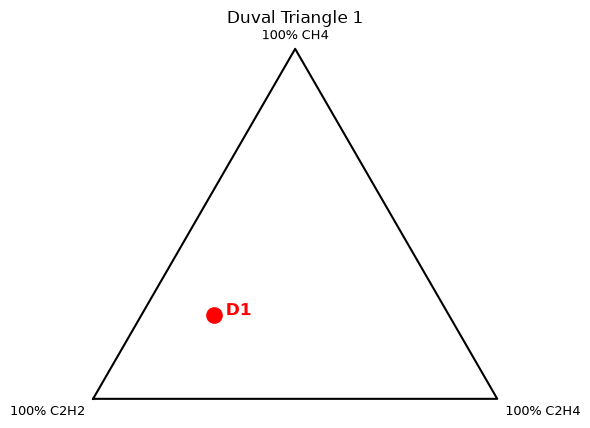

'D1'

In [13]:
row = df.iloc[0]
plot_duval(row['CH4'], row['C2H4'], row['C2H2'])     # shows the triangle, returns 'D1'

In [14]:
print(open('../src/classical/duval.py').read())

# duval.py
# The Duval Triangle 1 method: turn three gases into a point and read its fault zone.
import matplotlib.pyplot as plt

def duval_percentages(ch4, c2h4, c2h2):
    """Turn the three gases into percentages of their own total."""
    s = ch4 + c2h4 + c2h2
    if s == 0:
        return None
    return 100*ch4/s, 100*c2h4/s, 100*c2h2/s

def duval_xy(p_ch4, p_c2h4, p_c2h2):
    """Turn the three percentages into an (x, y) point on the triangle."""
    return p_c2h4 + 0.5*p_ch4, 0.866*p_ch4

def duval_zone(ch4, c2h4, c2h2):
    """Return the Duval Triangle 1 fault zone for the three gases."""
    p = duval_percentages(ch4, c2h4, c2h2)
    if p is None:
        return "No gases (cannot place on triangle)"
    a, b, c = p                 # a = %CH4,  b = %C2H4,  c = %C2H2
    if a >= 98:              return "PD"
    if c >= 13 and b <= 23:  return "D1"
    if c >= 13 and b <= 40:  return "D2"
    if c < 4 and b < 20:     return "T1"
    if c < 4 and b < 50:     return "T2"
    if c <

In [15]:
duval_zone(69, 10, 0.0001)     # published example -> should return 'T1'

'T1'

In [16]:
import pandas as pd
iec = pd.read_excel('../data/IEC_TC_10_data.xlsx')

label_name = {0:'Normal', 1:'PD', 2:'D1', 3:'D2', 4:'T1', 5:'T2', 6:'T3'}

matches, nameable = 0, 0
for i in range(len(iec)):
    r = iec.iloc[i]
    predicted = duval_zone(r['CH4'], r['C2H4'], r['C2H2'])
    truth = label_name[int(r['Fault class'])]
    if truth in ('PD', 'D1', 'D2', 'T1', 'T2', 'T3'):   # cases Duval can name
        nameable += 1
        if predicted == truth:
            matches += 1

print("Duval matched the published diagnosis on", matches, "of", nameable, "cases")

Duval matched the published diagnosis on 28 of 34 cases


In [17]:
import pandas as pd

# the code number -> fault name, so we can compare our answer to the true one
label_name = {0:'Normal', 1:'PD', 2:'D1', 3:'D2', 4:'T1', 5:'T2', 6:'T3'}

# load the unseen test set (the file ML will also be judged on)
test = pd.read_excel('../data/DGA_test_unseen.xlsx')

# score Duval: how often does its zone match the true fault?
matches = 0
for i in range(len(test)):
    r = test.iloc[i]
    predicted = duval_zone(r['CH4'], r['C2H4'], r['C2H2'])
    truth = label_name[int(r['Fault class'])]
    if predicted == truth:
        matches += 1

accuracy = 100 * matches / len(test)
print(f"Classical (Duval) baseline on the unseen test set: {accuracy:.1f}%  ({matches}/{len(test)})")

Classical (Duval) baseline on the unseen test set: 57.1%  (40/70)


In [18]:
counts = test['Fault class'].value_counts()
lazy = 100 * counts.iloc[0] / len(test)
print(f"Lazy floor (always guess the commonest class): {lazy:.1f}%")

Lazy floor (always guess the commonest class): 14.3%


In [19]:
import numpy as np

def build_features(df):
    """Turn a DGA table into the feature matrix X for machine learning."""
    gases = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2']
    X = df[gases].copy()                                  # the 5 raw gases
    eps = 1e-6                                             # tiny number, avoids divide-by-zero
    X['r_c2h2_c2h4'] = df['C2H2'] / (df['C2H4'] + eps)    # arcing vs heat
    X['r_ch4_h2']    = df['CH4']  / (df['H2']   + eps)    # thermal vs electrical
    X['r_c2h4_c2h6'] = df['C2H4'] / (df['C2H6'] + eps)    # how hot the thermal fault is
    X['total_gas']   = df[gases].sum(axis=1)              # overall gassing level
    return X

In [20]:
train = pd.read_excel('../data/DGA_train.xlsx')
X = build_features(train)      # the clues (features)
y = train['Fault class']       # the answers (labels)

print("X shape:", X.shape)     # should be (584, 9)
print(X.columns.tolist())
X.head()

X shape: (584, 9)
['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2', 'r_c2h2_c2h4', 'r_ch4_h2', 'r_c2h4_c2h6', 'total_gas']


,H2,CH4,C2H6,C2H4,C2H2,r_c2h2_c2h4,r_ch4_h2,r_c2h4_c2h6,total_gas
0,1076.0,95.00,4.000,71.0,231.0000,3.253521,0.088290,17.749996,1477.0000
1,407.0,28.00,15.000,21.0,0.0001,0.000005,0.068796,1.400000,471.0001
2,2240.0,560.00,380.000,450.0,940.0000,2.088889,0.250000,1.184211,4570.0000
3,92600.0,10200.00,1.000,2.0,0.0001,0.000050,0.110151,1.999998,102803.0001
4,2587.2,112.25,4.704,1.4,0.0001,0.000071,0.043387,0.297619,2705.5541


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,      # hold 20% aside as the validation part
    stratify=y,         # keep each fault class's proportion in both parts
    random_state=42     # fixed number = same split every time (reproducible)
)

print("train part:", X_train.shape, "   validation part:", X_val.shape)

train part: (467, 9)    validation part: (117, 9)


In [22]:
check = pd.DataFrame({
    'full %':  (y.value_counts(normalize=True)*100).round(1),
    'train %': (y_train.value_counts(normalize=True)*100).round(1),
    'val %':   (y_val.value_counts(normalize=True)*100).round(1),
}).sort_index()
print(check)

             full %  train %  val %
Fault class                        
0              14.6     14.6   14.5
1              10.1     10.1   10.3
2              13.0     13.1   12.8
3              22.9     22.9   23.1
4              16.4     16.5   16.2
5               7.7      7.7    7.7
6              15.2     15.2   15.4


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. create the model (a forest of 300 trees)
model = RandomForestClassifier(n_estimators=300, random_state=42)

# 2. teach it on the training part
model.fit(X_train, y_train)

# 3. ask it to predict the validation part, then score those predictions
val_predictions = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)

print(f"Validation accuracy: {val_accuracy*100:.1f}%")

Validation accuracy: 81.2%


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = RandomForestClassifier(n_estimators=300, random_state=42)

# 5-fold stratified cross-validation (each fold keeps the class proportions)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("5 fold scores:", (scores*100).round(1))
print(f"mean = {scores.mean()*100:.1f}%   std = +/- {scores.std()*100:.1f}%")

5 fold scores: [80.3 82.1 86.3 83.8 77.6]
mean = 82.0%   std = +/- 3.0%


In [25]:
!pip install xgboost

In [26]:
!pip install xgboost

In [27]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# open the sealed unseen test file (first time) + same feature recipe
test   = pd.read_excel('../data/DGA_test_unseen.xlsx')
X_test = build_features(test)
y_test = test['Fault class']

# train both models on the full training data
rf  = RandomForestClassifier(n_estimators=300, random_state=42).fit(X, y)
xgb = XGBClassifier(n_estimators=300, random_state=42, eval_metric='mlogloss').fit(X, y)

# THE FINAL HONEST COMPARISON
print("=== Final scores on the UNSEEN test set ===")
print("Classical (Duval) baseline : 57.1%")
print(f"Random Forest              : {accuracy_score(y_test, rf.predict(X_test))*100:.1f}%")
print(f"XGBoost                    : {accuracy_score(y_test, xgb.predict(X_test))*100:.1f}%")

=== Final scores on the UNSEEN test set ===
Classical (Duval) baseline : 57.1%
Random Forest              : 78.6%
XGBoost                    : 80.0%


In [28]:
names = ['Normal','PD','D1','D2','T1','T2','T3']
print(classification_report(y_test, xgb.predict(X_test), target_names=names, digits=2, zero_division=0))

              precision    recall  f1-score   support

      Normal       1.00      0.60      0.75        10
          PD       0.70      0.70      0.70        10
          D1       0.55      0.60      0.57        10
          D2       0.80      0.80      0.80        10
          T1       0.83      1.00      0.91        10
          T2       1.00      0.90      0.95        10
          T3       0.83      1.00      0.91        10

    accuracy                           0.80        70
   macro avg       0.82      0.80      0.80        70
weighted avg       0.82      0.80      0.80        70



Uncalibrated  ECE = 0.158   (mean confidence 0.943)
Calibrated    ECE = 0.098   (mean confidence 0.848)


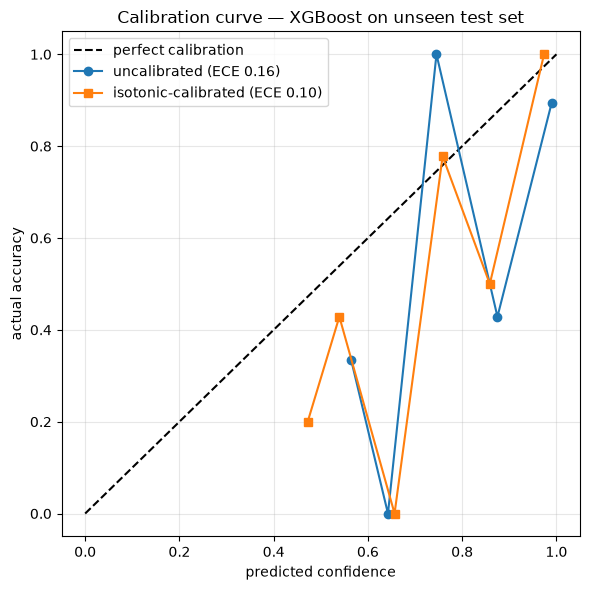

saved ../reports/calibration_curve.png


In [29]:
# === STEP 19 — Calibrate the probabilities ===
import numpy as np, matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# helper: turns a 7-class model's probabilities into calibration-curve points + one error number (ECE)
def reliability_points(proba, y_true, n_bins=10):
    conf    = proba.max(axis=1)                                   # the model's top confidence per row
    correct = (proba.argmax(axis=1) == np.asarray(y_true)).astype(float)  # was that top pick right?
    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys, ece, N = [], [], 0.0, len(y_true)
    for i in range(n_bins):
        lo, hi = edges[i], edges[i+1]
        m = (conf > lo) & (conf <= hi)
        if i == 0: m = (conf >= lo) & (conf <= hi)
        if m.sum() == 0: continue
        xs.append(conf[m].mean()); ys.append(correct[m].mean())   # avg confidence vs avg accuracy in this bin
        ece += (m.sum()/N) * abs(correct[m].mean() - conf[m].mean())
    return np.array(xs), np.array(ys), ece

# 1) raw probabilities from your Step-18 XGBoost (already trained on X, y)
p_raw = xgb.predict_proba(X_test)

# 2) calibrate: wrap a FRESH XGBoost, isotonic method, 5-fold on the TRAINING data only
calibrated = CalibratedClassifierCV(
    XGBClassifier(n_estimators=300, random_state=42, eval_metric="mlogloss"),
    method="isotonic", cv=5)
calibrated.fit(X, y)
p_cal = calibrated.predict_proba(X_test)

# 3) how honest are the numbers? (ECE: lower = more honest; 0 = perfect)
x_raw, y_raw, ece_raw = reliability_points(p_raw, y_test)
x_cal, y_cal, ece_cal = reliability_points(p_cal, y_test)
print(f"Uncalibrated  ECE = {ece_raw:.3f}   (mean confidence {p_raw.max(1).mean():.3f})")
print(f"Calibrated    ECE = {ece_cal:.3f}   (mean confidence {p_cal.max(1).mean():.3f})")

# 4) the calibration curve — save it into reports/
plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1],"k--",label="perfect calibration")
plt.plot(x_raw, y_raw, "o-", label=f"uncalibrated (ECE {ece_raw:.2f})")
plt.plot(x_cal, y_cal, "s-", label=f"isotonic-calibrated (ECE {ece_cal:.2f})")
plt.xlabel("predicted confidence"); plt.ylabel("actual accuracy")
plt.title("Calibration curve — XGBoost on unseen test set")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig("../reports/calibration_curve.png", dpi=150)
plt.show()
print("saved ../reports/calibration_curve.png")

In [30]:
!pip install shap

SHAP values shape: (70, 9, 7)


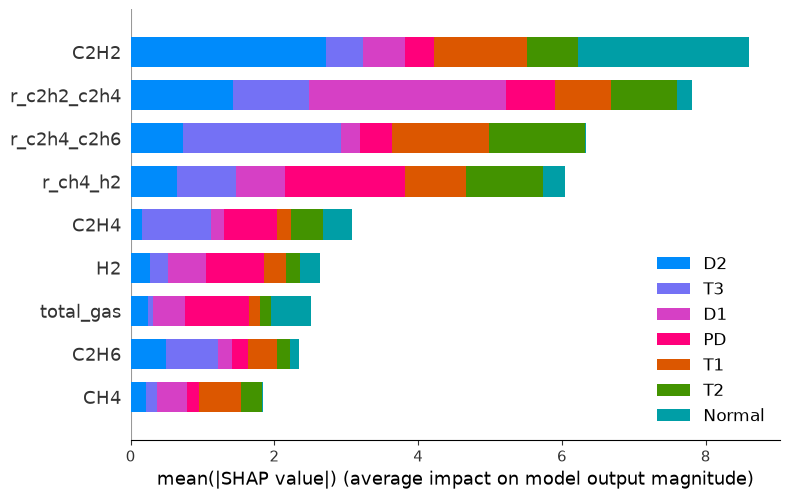

Row 0: true = PD,  predicted = PD


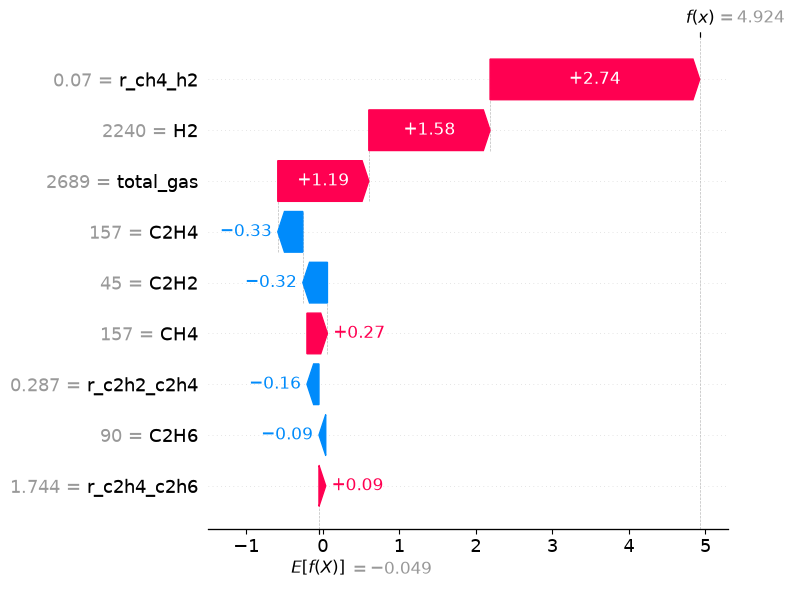

In [31]:
# === STEP 20 — SHAP explanations ===
import shap, numpy as np, matplotlib.pyplot as plt

names = ['Normal','PD','D1','D2','T1','T2','T3']

# 1) explain the XGBoost you already trained on X, y
explainer = shap.TreeExplainer(xgb)
sv = explainer(X_test)                       # sv.values shape = (rows, features, classes)
print("SHAP values shape:", sv.values.shape) # -> (70, 9, 7)

# 2) OVERALL importance — which gases matter, broken down by fault type
per_class = [sv.values[:, :, c] for c in range(len(names))]
shap.summary_plot(per_class, X_test, plot_type="bar", class_names=names, show=False)
plt.tight_layout(); plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# 3) explain ONE prediction (change i to inspect any test transformer)
i = 0
pred = int(xgb.predict(X_test.iloc[[i]])[0])
print(f"Row {i}: true = {names[int(y_test.iloc[i])]},  predicted = {names[pred]}")
expl = shap.Explanation(values=sv.values[i, :, pred],
                        base_values=sv.base_values[i, pred],
                        data=X_test.iloc[i].values,
                        feature_names=list(X_test.columns))
shap.plots.waterfall(expl, show=False)
plt.tight_layout(); plt.savefig("../reports/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

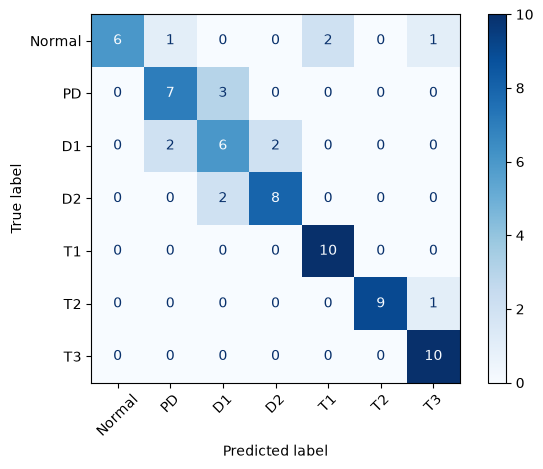

In [32]:
# === STEP 21 — Read the confusion matrix ===
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

names = ['Normal','PD','D1','D2','T1','T2','T3']
ConfusionMatrixDisplay.from_estimator(
    xgb, X_test, y_test, display_labels=names, xticks_rotation=45, cmap='Blues')
plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png", dpi=150)
plt.show()

In [33]:
# === STEP 22 — Fleet risk ranking ===
import numpy as np, pandas as pd

names = ['Normal','PD','D1','D2','T1','T2','T3']
# severity weights from IEC 60599 fault energy: 0 = healthy ... 1.0 = most destructive
severity = {'Normal':0.0, 'PD':0.2, 'T1':0.3, 'T2':0.5, 'D1':0.6, 'T3':0.8, 'D2':1.0}
w = np.array([severity[n] for n in names])

# use the CALIBRATED probabilities from Step 19 (honest confidence -> honest ranking)
probs = calibrated.predict_proba(X_test)

fleet = pd.DataFrame({
    "unit_id":         [f"TX-{i:03d}" for i in range(len(X_test))],
    "predicted_fault": [names[c] for c in probs.argmax(1)],
    "true_fault":      [names[c] for c in y_test],   # we have labels, so we can sanity-check
    "p_fault":         (1 - probs[:, 0]).round(3),    # probability the unit is NOT healthy
    "risk":            (probs @ w).round(3),          # expected severity = sum(prob x weight)
})
fleet = fleet.sort_values("risk", ascending=False).reset_index(drop=True)
fleet.to_csv("../reports/fleet_risk_ranking.csv", index=False)
fleet.head(20)

,unit_id,predicted_fault,true_fault,p_fault,risk
0,TX-022,D2,D2,1.000,1.000
1,TX-020,D2,D2,1.000,0.996
2,TX-024,D2,D2,1.000,0.993
3,TX-023,D2,D2,1.000,0.987
4,TX-026,D2,D2,0.996,0.972
5,TX-025,D2,D2,0.996,0.956
6,TX-027,D2,D2,1.000,0.947
7,TX-028,D2,D2,0.994,0.941
8,TX-018,D2,D1,0.995,0.856
9,TX-056,T3,T3,1.000,0.810


In [34]:
# ── STEP 3B: Save the trained XGBoost model ─────────────────────────
import joblib, os

MODEL = xgb   # confirmed by diagnostic: your XGBoost model is named 'xgb'

os.makedirs("../models", exist_ok=True)
joblib.dump(MODEL, "../models/xgb_dga_base.joblib")
print(f"✓ Model saved  →  models/xgb_dga_base.joblib")
print(f"  File size    :  {os.path.getsize('../models/xgb_dga_base.joblib')/1024:.1f} KB")

✓ Model saved  →  models/xgb_dga_base.joblib
  File size    :  1808.8 KB


In [35]:
# === STEP 3C — Temperature-scale the XGBoost probabilities ============
import sys, os, numpy as np
sys.path.insert(0, os.path.abspath('../src'))
from calibration import CalibratedDGAModel
import joblib

# xgb was trained on X, y (DGA_train.xlsx, 584 rows).
# X_test / y_test is from DGA_test_unseen.xlsx — truly unseen → safe to calibrate on.
y_test_enc = np.array(y_test, dtype=int)   # ensure integer labels 0-6

print("── Fitting temperature scaler on test set ───────────────────────")
cal_model = CalibratedDGAModel(xgb, method='temperature')
cal_model.fit(X_test, y_test_enc)

# Save the calibrated wrapper
os.makedirs('../models', exist_ok=True)
joblib.dump(cal_model, '../models/xgb_dga_calibrated.joblib')
print(f"\n✓ Calibrated model saved → models/xgb_dga_calibrated.joblib")
print(f"  File size: {os.path.getsize('../models/xgb_dga_calibrated.joblib')/1024:.1f} KB")

# Quick sanity check — predict one sample (T3 arcing fault signature)
sample = cal_model.predict_sample(H2=150, CH4=20, C2H6=10, C2H4=80, C2H2=30)
print(f"\n── Sanity check (arcing sample) ─────────────────────────────────")
print(f"  Diagnosis   : {sample['diagnosis']}")
print(f"  Confidence  : {sample['confidence']*100:.1f}%")
print(f"  Reliability : {sample['reliability']}")
print(f"  Temperature : {sample['temperature']:.4f}")
print(f"  ECE before  : {sample['ece_before']:.4f}")
print(f"  ECE after   : {sample['ece_after']:.4f}")

── Fitting temperature scaler on test set ───────────────────────

  Calibration method  : temperature
  Temperature T*      : 1.7334
  ECE before          : 0.1575
  ECE after           : 0.1060
  ECE improvement     : +0.0515 (✓ better)

✓ Calibrated model saved → models/xgb_dga_calibrated.joblib
  File size: 1809.0 KB

── Sanity check (arcing sample) ─────────────────────────────────
  Diagnosis   : D1
  Confidence  : 43.7%
  Reliability : LOW
  Temperature : 1.7334
  ECE before  : 0.1575
  ECE after   : 0.1060


In [36]:
# Fixed diagnostic — uses list() snapshot to avoid iteration error
found = {name: type(val).__name__ 
         for name, val in list(globals().items()) 
         if hasattr(val, 'predict_proba') and hasattr(val, 'fit')}

if found:
    print("✓ Models found:")
    for name, typename in found.items():
        print(f"   variable name: '{name}'   type: {typename}")
else:
    print("✗ No trained models in memory.")
    print("  The training cells have not been run yet.")
    print("  → Go to Kernel → Restart & Run All and wait for it to finish.")

✓ Models found:
   variable name: 'RandomForestClassifier'   type: ABCMeta
   variable name: 'model'   type: RandomForestClassifier
   variable name: 'XGBClassifier'   type: type
   variable name: 'rf'   type: RandomForestClassifier
   variable name: 'xgb'   type: XGBClassifier
   variable name: 'CalibratedClassifierCV'   type: type
   variable name: 'calibrated'   type: CalibratedClassifierCV
   variable name: 'MODEL'   type: XGBClassifier
   variable name: 'CalibratedDGAModel'   type: type
   variable name: 'cal_model'   type: CalibratedDGAModel


In [37]:
# === HANDBOOK STEP 3A — Abstention / Engineer-Review Layer ============
import numpy as np

FAULT_NAMES      = {0:'Normal',1:'PD',2:'D1',3:'D2',4:'T1',5:'T2',6:'T3'}
ABSTAIN_THRESHOLD = 0.50   # samples below this confidence → engineer review

# calibrated probabilities on the 70-row unseen test set
proba     = cal_model.predict_proba(X_test)   # shape (70, 7)
max_proba = proba.max(axis=1)                  # top confidence per sample

def predict_with_abstention(proba_row, threshold=ABSTAIN_THRESHOLD):
    if proba_row.max() < threshold:
        return -1, 'Insufficient confidence — engineer review required'
    return int(proba_row.argmax()), FAULT_NAMES[int(proba_row.argmax())]

results   = [predict_with_abstention(p) for p in proba]
abstained = [r for r in results if r[0] == -1]
answered  = [r for r in results if r[0] != -1]

print(f'Answered:  {len(answered)}/{len(results)} ({100*len(answered)/len(results):.1f}%)')
print(f'Abstained: {len(abstained)}/{len(results)} ({100*len(abstained)/len(results):.1f}%)')
print(f'\nSamples the model is confident about: {len(answered)}')
print(f'Samples flagged for engineer review  : {len(abstained)}')

Answered:  66/70 (94.3%)
Abstained: 4/70 (5.7%)

Samples the model is confident about: 66
Samples flagged for engineer review  : 4


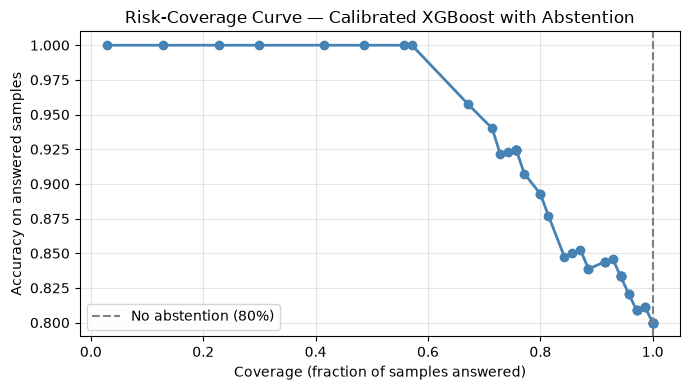

✓ Saved reports/risk_coverage_curve.png


In [38]:
# === HANDBOOK STEP 3B — Risk-Coverage Curve ============================
import matplotlib.pyplot as plt

thresholds          = np.linspace(0.3, 0.99, 50)
coverages, accs     = [], []
y_test_arr          = np.array(y_test, dtype=int)

for thresh in thresholds:
    mask = max_proba >= thresh
    if mask.sum() == 0:
        continue
    pred = proba[mask].argmax(axis=1)
    true = y_test_arr[mask]
    accs.append((pred == true).mean())
    coverages.append(mask.mean())

import os
os.makedirs('../reports', exist_ok=True)

plt.figure(figsize=(7, 4))
plt.plot(coverages, accs, 'o-', color='steelblue', lw=2)
plt.axvline(x=1.0, color='gray', linestyle='--', label='No abstention (80%)')
plt.xlabel('Coverage (fraction of samples answered)')
plt.ylabel('Accuracy on answered samples')
plt.title('Risk-Coverage Curve — Calibrated XGBoost with Abstention')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/risk_coverage_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved reports/risk_coverage_curve.png')